<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-8 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> Neural Networks in Finance </h2> </html>

### Silver: 6-months-2023 dataset
### LSTM (Long Short-Term Memory)
     
### Predictions of The Highest & Lowest prices DURING 25 following minutes
- Early-Stopping
- Loss function: MSE

### length of analysed history (sliding window)- 50 rows ~ 4 hours ago

#### dataset for training: 35.220 rows (5-minutes) = 6 months
#### train / test = 90 /10

In [42]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

from matplotlib import *
import seaborn as sns


In [43]:
import tensorflow as tf
from tensorflow import keras

In [44]:
print(tf.__version__)

2.20.0


In [45]:
# Early Stopping libraries

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

In [46]:
np.random.seed(19)

<html> <h3 style="font-style:italic; color:blue;"> Data</h3> </html>

In [47]:
# A preprocessed and normalised dataset is used.
# The dataset includes indicators for the start of the day and the start of the week.

# We use different normalisation principles for prices. All Silver prices are divided by 10.
# We use the typical normalisation principle for Volumes and Deltas.

# For normalisation, it is not necessary for the normalised columns' values to be in the range between [0,1].
# What is more important is that all the values in these columns are approximately the same order of magnitude,
# i.e. do not differ by hundreds or more times.

In [48]:
data = pd.read_csv('Silver_6m_2023_normalised_NEW-10-1.csv', low_memory=False, sep=',')
data.head()

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,New_day,New_week,Y_High_Bid,Y_Low_Ask
0,2.4036,2.4059,2.4017,2.4059,0.000952,2.4102,2.4125,2.4083,2.4125,0.000960,0.133180,0.000009,0.840686,0.840686,0.840686,0.840686,1,1,2.4059,2.4083
1,2.4064,2.4130,2.4064,2.4092,0.005048,2.4094,2.4188,2.4094,2.4141,0.003159,0.131287,0.002175,0.928922,0.860294,0.928922,0.882353,0,0,2.4130,2.4094
2,2.4094,2.4098,2.3972,2.3977,0.002470,2.4143,2.4148,2.4022,2.4027,0.002412,0.133115,0.000066,0.882353,0.879902,0.879902,0.879902,0,0,2.4098,2.4022
3,2.3977,2.3980,2.3938,2.3980,0.002445,2.4026,2.4028,2.3986,2.4028,0.002445,0.133172,0.000000,0.882353,0.884804,0.884804,0.884804,0,0,2.3980,2.3986
4,2.3978,2.4024,2.3976,2.4023,0.002429,2.4026,2.4073,2.4023,2.4073,0.002474,0.133217,0.000052,0.884804,0.882353,0.887255,0.879902,0,0,2.4024,2.4023


In [49]:
data.tail()

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,New_day,New_week,Y_High_Bid,Y_Low_Ask
35215,2.2752,2.2752,2.2741,2.2746,0.000753,2.2782,2.2782,2.2771,2.2776,0.004924,0.137334,0.004802,0.928922,0.928922,0.928922,0.928922,0,0,2.2752,2.2771
35216,2.2736,2.2751,2.2736,2.2746,0.000386,2.2775,2.2781,2.2775,2.2776,0.002070,0.134853,0.001939,0.906863,0.928922,0.906863,0.928922,0,0,2.2751,2.2775
35217,2.2751,2.2751,2.2746,2.2746,0.000189,2.2781,2.2781,2.2776,2.2776,0.001152,0.134133,0.001109,0.928922,0.928922,0.928922,0.928922,0,0,2.2751,2.2776
35218,2.2746,2.2761,2.2736,2.2756,0.000591,2.2776,2.2797,2.2774,2.2786,0.001870,0.134448,0.001472,0.928922,0.914216,0.909314,0.928922,0,0,2.2761,2.2774
35219,2.2756,2.2766,2.2701,2.2745,0.000894,2.2786,2.2811,2.2786,2.2811,0.001015,0.133293,0.000139,0.928922,0.892157,0.794118,0.840686,0,0,2.2766,2.2786


In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35220 entries, 0 to 35219
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          35220 non-null  float64
 1   High_Bid          35220 non-null  float64
 2   Low_Bid           35220 non-null  float64
 3   Close_Bid         35220 non-null  float64
 4   Volume_Bid        35220 non-null  float64
 5   Open_Ask          35220 non-null  float64
 6   High_Ask          35220 non-null  float64
 7   Low_Ask           35220 non-null  float64
 8   Close_Ask         35220 non-null  float64
 9   Volume_Ask        35220 non-null  float64
 10  Volume_Delta      35220 non-null  float64
 11  Volume_Delta_abs  35220 non-null  float64
 12  Open_Delta        35220 non-null  float64
 13  High_Delta        35220 non-null  float64
 14  Low_Delta         35220 non-null  float64
 15  Close_Delta       35220 non-null  float64
 16  New_day           35220 non-null  int64 

In [51]:
# memory size reduction

columns_float =['Open_Bid', 'High_Bid', 'Low_Bid', 'Close_Bid', 'Volume_Bid',
                'Open_Ask', 'High_Ask', 'Low_Ask', 'Close_Ask', 'Volume_Ask',
                'Volume_Delta', 'Volume_Delta_abs',
                'Open_Delta', 'High_Delta', 'Low_Delta', 'Close_Delta',
                'Y_High_Bid', 'Y_Low_Ask']

columns_integer =['New_day', 'New_week']



In [52]:
for column in columns_float:
    data[column] = pd.to_numeric(data[column], downcast='float')

for column in columns_integer:
    data[column] = pd.to_numeric(data[column], downcast='integer')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35220 entries, 0 to 35219
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          35220 non-null  float32
 1   High_Bid          35220 non-null  float32
 2   Low_Bid           35220 non-null  float32
 3   Close_Bid         35220 non-null  float32
 4   Volume_Bid        35220 non-null  float32
 5   Open_Ask          35220 non-null  float32
 6   High_Ask          35220 non-null  float32
 7   Low_Ask           35220 non-null  float32
 8   Close_Ask         35220 non-null  float32
 9   Volume_Ask        35220 non-null  float32
 10  Volume_Delta      35220 non-null  float32
 11  Volume_Delta_abs  35220 non-null  float32
 12  Open_Delta        35220 non-null  float32
 13  High_Delta        35220 non-null  float32
 14  Low_Delta         35220 non-null  float32
 15  Close_Delta       35220 non-null  float32
 16  New_day           35220 non-null  int8  

In [53]:
data.describe()

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,New_day,New_week,Y_High_Bid,Y_Low_Ask
count,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,3.522000e+04,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000
mean,2.335737,2.337461,2.333843,2.335737,0.022654,2.338758,2.340482,2.336870,2.338750,0.095985,0.206354,0.084729,0.928403,0.928402,9.282691e-01,0.928593,0.003634,0.000738,2.337461,2.336870
std,0.136878,0.136883,0.136893,0.136887,0.024550,0.136878,0.136879,0.136895,0.136886,0.106733,0.091225,0.104995,0.007956,0.008288,1.229153e-02,0.009445,0.060176,0.027161,0.136883,0.136895
min,1.989300,1.991400,1.988800,1.989300,0.000000,1.992300,1.994400,1.991800,1.992300,0.000000,0.000000,0.000000,0.549020,0.458333,2.585078e-15,0.245098,0.000000,0.000000,1.991400,1.991800
25%,2.242175,2.244000,2.240000,2.242100,0.007141,2.245200,2.247000,2.243000,2.245100,0.025894,0.147285,0.016490,0.928922,0.928922,9.289216e-01,0.928922,0.000000,0.000000,2.244000,2.243000
50%,2.356000,2.357600,2.354300,2.356000,0.014580,2.359000,2.360700,2.357300,2.359000,0.060819,0.173862,0.047034,0.928922,0.928922,9.289216e-01,0.928922,0.000000,0.000000,2.357600,2.357300
75%,2.412200,2.414400,2.410300,2.412200,0.029227,2.415300,2.417400,2.413300,2.415200,0.127558,0.231854,0.113856,0.928922,0.928922,9.289216e-01,0.928922,0.000000,0.000000,2.414400,2.413300
max,2.611800,2.612300,2.609800,2.611800,0.329981,2.614800,2.615300,2.612800,2.614800,1.000000,1.000000,1.000000,0.975490,0.958333,1.000000e+00,0.973039,1.000000,1.000000,2.612300,2.612800


In [54]:
data.shape

(35220, 20)

<html> <h3 style="font-style:italic; color:blue;"> Data Visualisation </h3> </html>

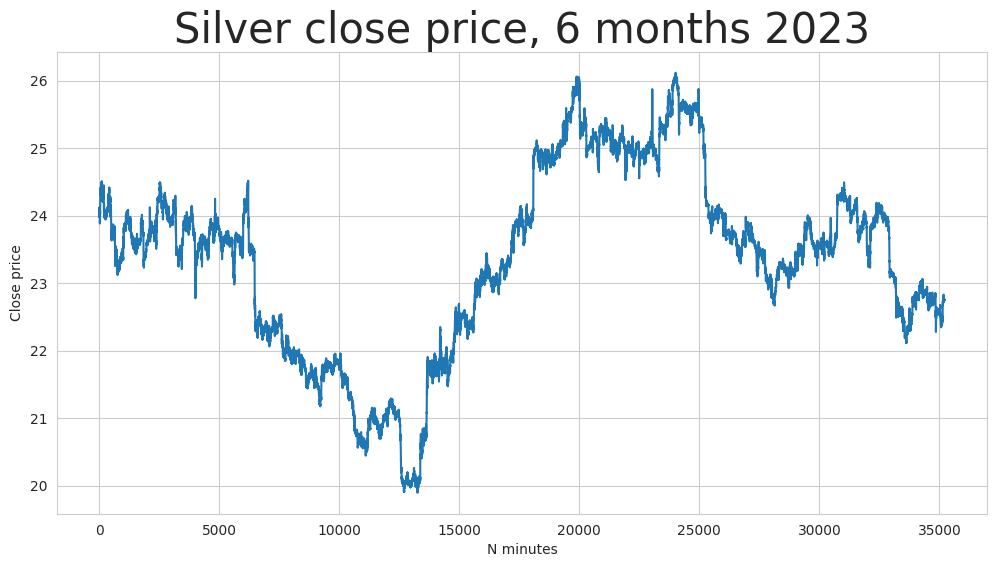

In [55]:
plt.figure(figsize=(12,6))
plt.plot(data['Close_Bid']*10)
plt.title('Silver close price, 6 months 2023')
plt.xlabel('N minutes')
plt.ylabel('Close price')
plt.show()

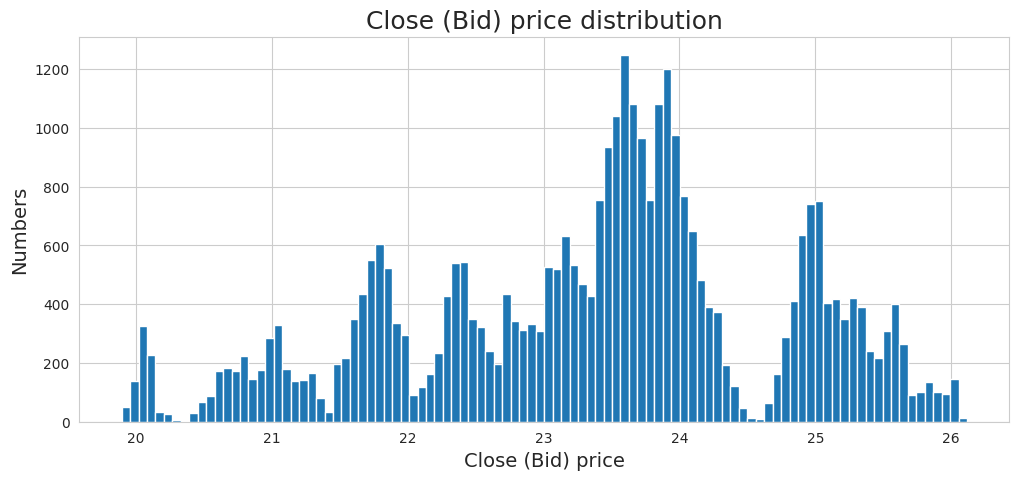

In [56]:
plt.figure(num=1,figsize=(12,5))
plt.hist(data['Close_Bid']*10,bins=100)
plt.title('Close (Bid) price distribution',size=18)
plt.ylabel('Numbers',size=14)
plt.xlabel('Close (Bid) price',size=14)
plt.show();

<Figure size 1200x500 with 0 Axes>

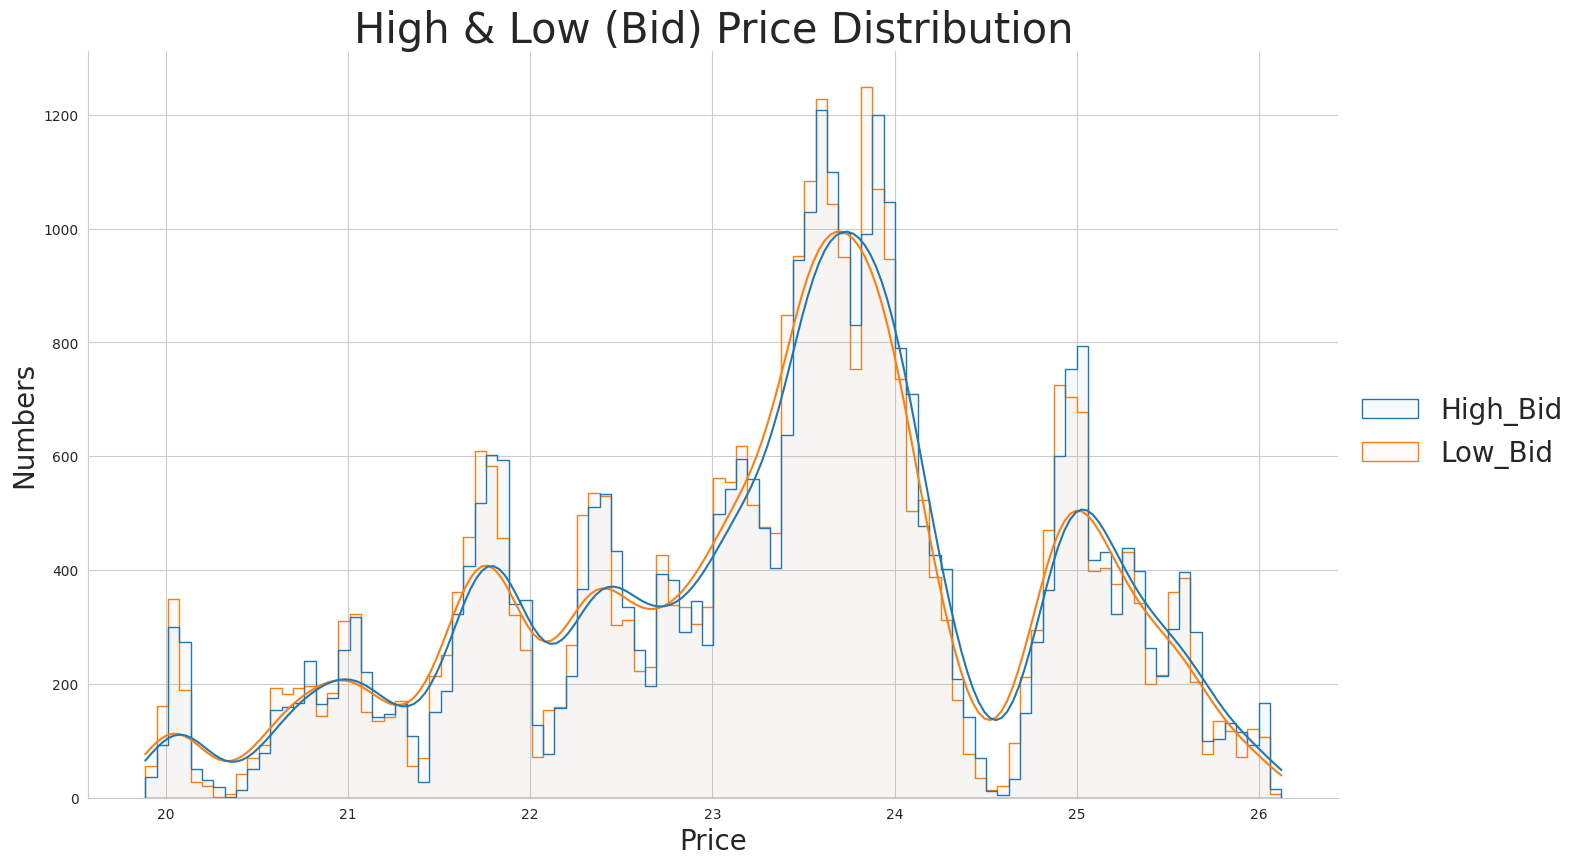

In [57]:
fig = plt.figure(figsize=(12, 5))
plt.rc('axes', titlesize= 30 )
sns.set_style('whitegrid')
sns.set_context(rc={'legend.fontsize': 20.0})

sns.displot(
            data[['High_Bid', 'Low_Bid']]*10,
            height=8,
            aspect=1.7,
            #hue="species",
            kde=True,
            element="step",
            bins=100,
            alpha=0.03,

)

plt.title('High & Low (Bid) Price Distribution')
plt.xlabel('Price', size= 20)
#plt.ylabel('count (%)')
plt.ylabel('Numbers', size= 20)
plt.show();

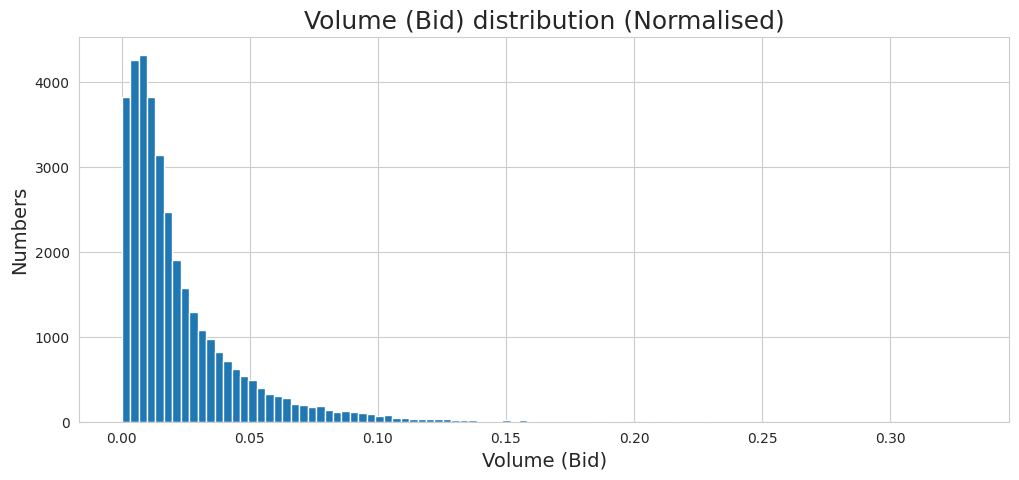

In [58]:
plt.figure(num=1,figsize=(12,5))
plt.hist(data['Volume_Bid'],bins=100)
plt.title('Volume (Bid) distribution (Normalised)',size=18)
plt.ylabel('Numbers',size=14)
plt.xlabel('Volume (Bid)',size=14)
plt.show();

<Figure size 1200x500 with 0 Axes>

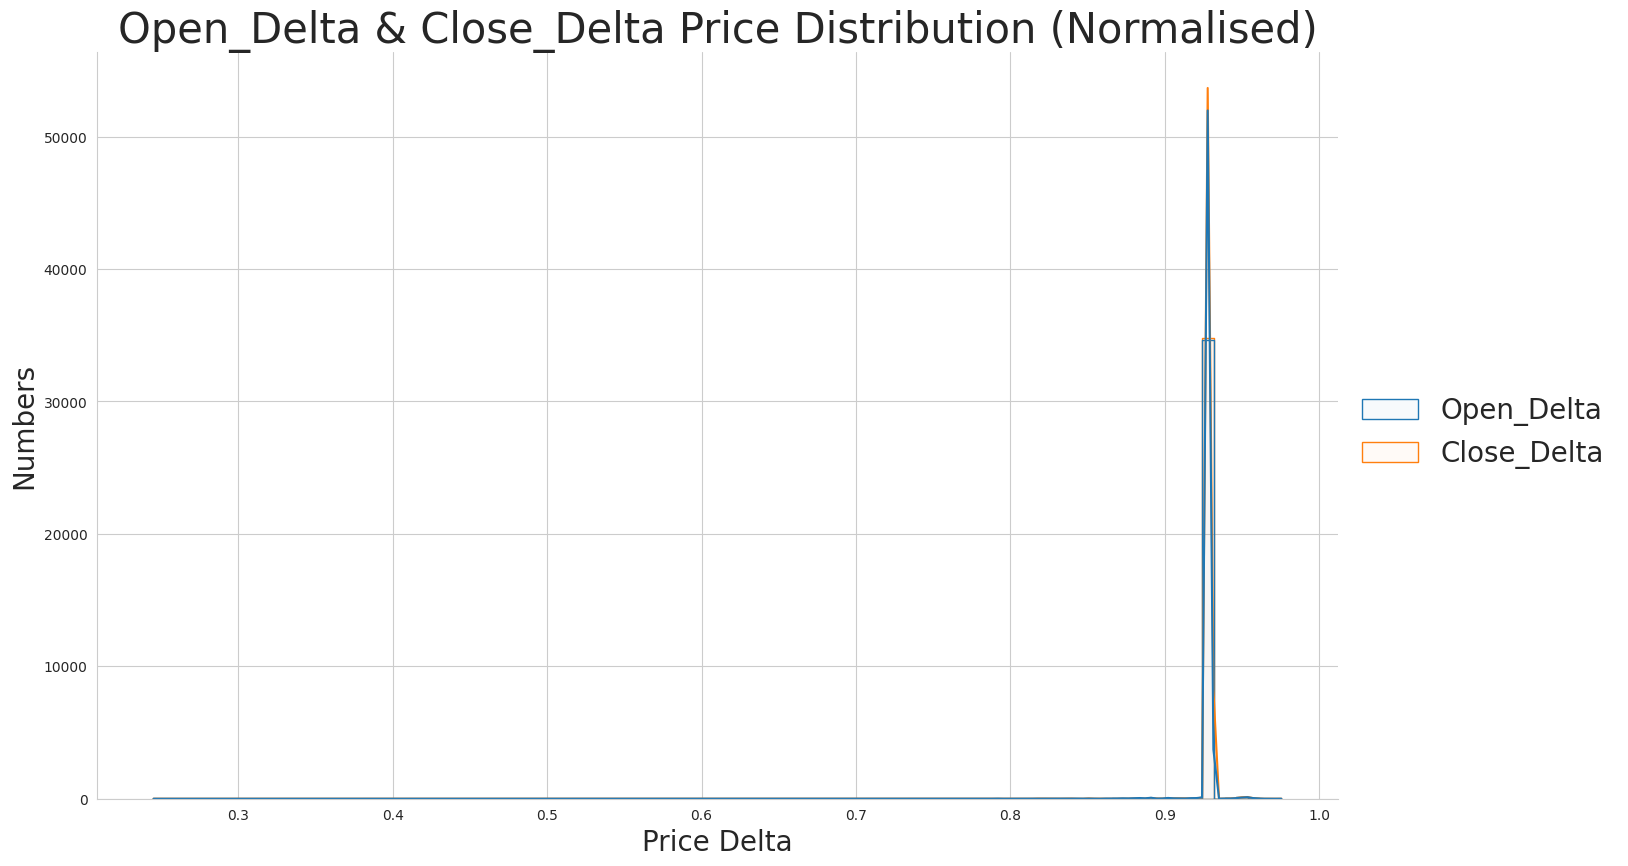

In [59]:
fig = plt.figure(figsize=(12, 5))
plt.rc('axes', titlesize= 30 )
sns.set_style('whitegrid')
sns.set_context(rc={'legend.fontsize': 20.0})

sns.displot(
            data[['Open_Delta', 'Close_Delta']],
            height=8,
            aspect=1.7,
            kde=True,
            element="step",
            bins=100,
            alpha=0.03,

)

plt.title('Open_Delta & Close_Delta Price Distribution (Normalised)')
plt.xlabel('Price Delta', size= 20)
plt.ylabel('Numbers', size= 20)
plt.show();

<html> <h3 style="font-style:italic; color:blue;">Date transformation </h3> </html>


In [60]:
# We will predict the Highest and Lowest prices DURING the next 25 minutes (5rows * 5-minute time-frame).

# To do this in the data output (vector of answers), we shift prices sequentially to 25 minutes up (5rows),
# and find max and min prices during these 25 minutes
# Then you need to delete the 5 last rows since there are no prices for the next 25 minutes.
# Therefore, we will create an array of answers "data_ay" with the Highest and Lowest prices shifted sequentially to 5 rows up.

In [61]:
# Rows number

n=data.shape[0]
n

35220

In [62]:
# Colonms number

p=data.shape[1]
p

20

In [63]:
# create inputs Dataframe

data_ax = data.drop(['Y_High_Bid', 'Y_Low_Ask',axis=1)

SyntaxError: closing parenthesis ')' does not match opening parenthesis '[' (357930837.py, line 3)

In [ ]:
data_ax.info()

In [ ]:
data_ax.shape

In [ ]:
# create outputs Dataframe

data_ay = data[['Y_High_Bid', 'Y_Low_Ask']]

In [ ]:
data_ay.shape

In [ ]:
data_ay.head(6)

In [ ]:
data_ay.tail(10)

In [ ]:
# shift by one 5-minute(row) up
# We have to exclude the min and max prices of the current 5-minute row while further
# finding the min and max prices DURING the next 25 minutes

data_ay = data_ay.shift(-1)

In [ ]:
data_ay.head(6)

In [ ]:
data_ay.tail(10)

In [ ]:
# create new colomns: MIN_Lowest(Low_Ask) and MAX_Highest(High_Bid) prices of DURING NEXT 25 minutes

# Forward-looking window
indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=5)

data_ay['Y_High_Bid_25'] = data_ay['Y_High_Bid'].rolling(window=indexer).max()
data_ay['Y_Low_Ask_25']  = data_ay['Y_Low_Ask'].rolling(window=indexer).min()

In [ ]:
# The values in Y_High_Bid_25 and Y_Low_Ask_25 are equal to the maximum and minimum price (respectively)
# relative to the next 5 rows in Y_High_Bid and Y_Low_Ask

data_ay.head(10)

In [ ]:
# The values in Y_High_Bid_25 and Y_Low_Ask_25 are equal to the maximum and minimum price (respectively)
# relative to the next 5 rows in Y_High_Bid and Y_Low_Ask

data_ay.tail(10)

In [ ]:
# remove columns unused in further code

data_ay = data_ay.drop(['Y_High_Bid', 'Y_Low_Ask'],axis=1)

In [ ]:
data_ay.tail(6)

In [ ]:
# delete the 5 last rows in data_ax and data_ay (because we don't have answers(outputs) for the last 25 minutes)

for i in range(5):
    data_ax.drop(data_ax.shape[0]-1, axis=0, inplace=True)
    data_ay.drop(data_ay.shape[0]-1, axis=0, inplace=True)

In [ ]:
data_ay.shape

In [ ]:
data_ay.tail(3)

In [ ]:
data_ax.shape

#### Create numpy

In [64]:
# Create inputs and outputs Numpy

data_ax = data_ax.to_numpy()
data_ay = data_ay.to_numpy()

print(data_ax.shape, '\n', data_ay.shape)

AttributeError: 'numpy.ndarray' object has no attribute 'to_numpy'

<html> <h3 style="font-style:italic; color:blue;">Create the 3D inputs tensor, and 2D outputs matrix </h3> </html>

In [65]:
# We need a three-dimensional data tensor: [(n - N ), N, 18] and
# two-dimensional array of answers [(n - N ), 2] with the High and Low prices DURING the next 25 minutes


# where N=50 (equal to just over 4 hours) is the number of rows for analysis at each step; those are looking backwards

# Therefore, we need:
# three-dimensional data tensor of sliced graphs [(n - N - 5), N, 18] and
# two-dimensional matrix of answers Y[(n - N - 5), 2] with the High and Low prices shifted sequentially to 5 rows up.

In [66]:
# Progress bar

from tqdm import tqdm

In [67]:
n = len(data_ay)
n

35215

In [68]:
N = 50               # sliding window depth
L = n - N            # number of sliding window slices
t=data_ax.shape[1]   # features number

print('Size of a three-dimensional inputs tensor: ',L,N,t)


Size of a three-dimensional inputs tensor:  35165 50 18


In [69]:
# create imputs zeros 3D tensors with 'float32'

data_b = np.zeros( (L, N, t), dtype= 'float32' )

In [70]:
# create a two-dimensional zeros vector of answers - the High_Bid and Low_Ask prices DURING the next 25 minutes

Y = np.zeros((L, 2), dtype= 'float32')   # We will predict two prices - High_Bid and normalised Low_Ask

In [71]:
# fill the inputs 3D tensor (data_b)
# and the matrix of outputs Y

print('L = n - N - 5 = ', n-N-5, L)

for k in tqdm(range(L)):
    data_b[k, :, :] = data_ax[k:k+N, :]

    Y[k,0] = data_ay[k+N-1,0]   # Y_High_Bid_25 - max 25 minutes future price
    Y[k,1] = data_ay[k+N-1,1]   # Y_Low_Ask_25 -  min 25 minutes future price

print(k) # index value (for control)

print('data_b:', '\n', data_b)
print("Numpy size:        ", data_b.shape, '\n')

print( Y[:5,:])
print( Y[-10:,:])
print(      "Numpy size:         ", Y.shape)

L = n - N - 5 =  35160 35165


100%|██████████| 35165/35165 [00:00<00:00, 201094.69it/s]

35164
data_b: 
 [[[2.4036     2.4059     2.4017     ... 0.84068626 1.         1.        ]
  [2.4064     2.413      2.4064     ... 0.88235295 0.         0.        ]
  [2.4094     2.4098     2.3972     ... 0.87990195 0.         0.        ]
  ...
  [2.4218     2.4251     2.4212     ... 0.9289216  0.         0.        ]
  [2.4234     2.4255     2.422      ... 0.9289216  0.         0.        ]
  [2.4244     2.435      2.4237     ... 0.9289216  0.         0.        ]]

 [[2.4064     2.413      2.4064     ... 0.88235295 0.         0.        ]
  [2.4094     2.4098     2.3972     ... 0.87990195 0.         0.        ]
  [2.3977     2.398      2.3938     ... 0.88480395 0.         0.        ]
  ...
  [2.4234     2.4255     2.422      ... 0.9289216  0.         0.        ]
  [2.4244     2.435      2.4237     ... 0.9289216  0.         0.        ]
  [2.4345     2.435      2.4309     ... 0.9289216  0.         0.        ]]

 [[2.4094     2.4098     2.3972     ... 0.87990195 0.         0.        ]
  [2.3

In [72]:
# Control of the correctness of filling the array Y
# (should show MAX of the normalised prices High_Bid and Low_Ask - during 25 next minutes(5-step) ahead)

import random

pp = random.randint(50, L) # (random number less then 35115 = 35165-50)
print('random int = ', pp)

print('data_b:', '\t\t','Y:')
print('Y_High_Bid ','\t\t','Y_High_Bid')

for i in range(15):
    print(data_b[pp+i,N-1,1], '\t\t', Y[pp+i,0])


random int =  27433
data_b: 		 Y:
Y_High_Bid  		 Y_High_Bid
2.344 		 2.344
2.344 		 2.343
2.3428 		 2.3451
2.3417 		 2.3451
2.3406 		 2.3451
2.3409 		 2.3451
2.343 		 2.3451
2.3451 		 2.3441
2.3433 		 2.3441
2.3427 		 2.345
2.3421 		 2.3467
2.3441 		 2.3467
2.3441 		 2.3504
2.344 		 2.3517
2.345 		 2.3531


In [73]:
# Each rows of Y above must have maximum of prices of 5 row ahead

In [74]:
# Clean memory

data = []
data_ax = []
data_ay = []
data_a = []
data_y = []

<html> <h3 style="font-style:italic; color:blue;">Train Test Split </h3> </html>

- 90% for training and validation
- 10% for testing

In [75]:
from sklearn.model_selection import train_test_split

<html> <h3 style="font-style:bold; color:red;"> !!! Use parameters: shuffle = False, stratify = None

Otherwise, the whole time series will be mixed up!
</h3> </html>

In [76]:
# Separate "data_b" and "Y" into X_train, X_test, y_train, y_test i.e. getting training and testing set for the model.

X_train, X_test, y_train, y_test = train_test_split(data_b, Y, test_size=0.1,
                                                    shuffle = False, stratify = None,
                            # random_state - int for reproducible output across multiple function calls
                            # random_state=101
                                                   )

In [77]:
# Final control

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(31648, 50, 18)
(31648, 2)
(3517, 50, 18)
(3517, 2)


<html> <h3 style="font-style:italic; color:blue;">Training </h3> </html>

In [78]:
# LSTM

model = keras.Sequential([

    keras.layers.LSTM(31, activation='relu', input_shape=(50, 18)),

    keras.layers.Dense(2)

])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [79]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 31)             │         6,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │            64 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,264 (24.47 KB)

 Trainable params: 6,264 (24.47 KB)

 Non-trainable params: 0 (0.00 B)

None


#### Callbacks

In [80]:
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [81]:
es = EarlyStopping(monitor='val_loss', mode='min', patience=5, verbose=1)

In [82]:
mc = ModelCheckpoint('best_model_LSTM_Silver_3D_Tensor.keras', monitor='val_loss', mode='min', verbose=1, save_best_only=True)

<html> <h4 style="font-style:bold; color:blue;"> If you are using your own laptop without a GPU (Graphics processing unit),

please change the following parameter in the next cell

epochs=10
</h4> </html>


In [83]:
history = model.fit(X_train, y_train, batch_size=20, epochs=10,
                    validation_split=0.1,
                    verbose=1, callbacks=[es, mc])

Epoch 1/10
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0107 - mae: 0.0395
Epoch 1: val_loss improved from None to 0.00017, saving model to best_model_LSTM_Silver_3D_Tensor.keras

Epoch 1: finished saving model to best_model_LSTM_Silver_3D_Tensor.keras
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 0.0020 - mae: 0.0152 - val_loss: 1.7050e-04 - val_mae: 0.0105
Epoch 2/10
1424/1425 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0341e-04 - mae: 0.0072
Epoch 2: val_loss improved from 0.00017 to 0.00006, saving model to best_model_LSTM_Silver_3D_Tensor.keras

Epoch 2: finished saving model to best_model_LSTM_Silver_3D_Tensor.keras
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 1.0268e-04 - mae: 0.0071 - val_loss: 6.0737e-05 - val_mae: 0.0048
Epoch 3/10
1416/1425 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.2694e-05 - mae: 0.0068
Epoch 3: val_loss did not improve from 0.00006
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 1.0333e-04 - mae: 0.0073 - val_loss: 1.7984e-04 - val_m

In [84]:
# Upload the saved best model

LSTM_saved_best_model_Silver_3D = keras.models.load_model('best_model_LSTM_Silver_3D_Tensor.keras')

#### Test

In [85]:
# Evaluate the quality of network training on test data, which the network has NOT seen.

scores = LSTM_saved_best_model_Silver_3D.evaluate(X_test, y_test, verbose=1)

110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 6.6928e-05 - mae: 0.0049


In [86]:
scores

[6.692783063044772e-05, 0.0049157217144966125]

In [87]:
print("Mean squared error (mse): %.9f " % (scores[0]))

Mean squared error (mse): 0.000066928 


In [88]:
print("Mean absolute error (mae): %.9f " % (scores[1]))

Mean absolute error (mae): 0.004915722 


### Visualisation

#### MSE graphs during training

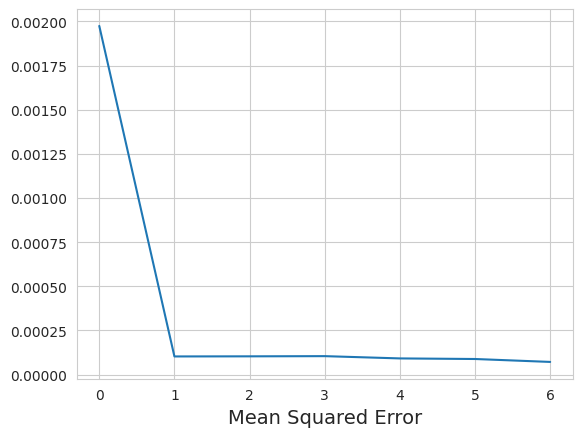

In [89]:
# Training Mean Squared Error (MSE)

plt.plot(history.history['loss'])
plt.xlabel('Mean Squared Error',size=14)
plt.show();

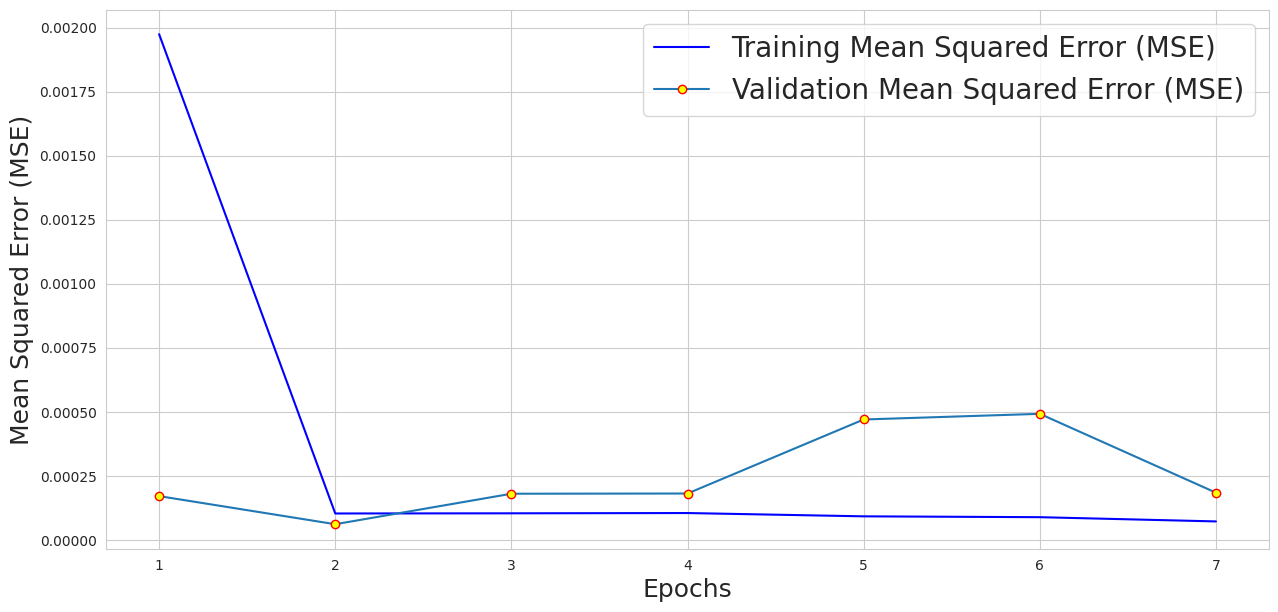

In [90]:
# More detailed MSE graph

history_dict = history.history

mse_values = history_dict['loss']
val_mse_values = history_dict['val_loss']

epochs = range(1, len(mse_values) + 1)
plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, mse_values, 'b', label='Training Mean Squared Error (MSE)')
plt.plot(epochs, val_mse_values, marker='o', markeredgecolor='red', markerfacecolor='yellow', label='Validation Mean Squared Error (MSE)')
plt.xlabel('Epochs', size=18)
plt.ylabel('Mean Squared Error (MSE)', size=18)
plt.legend()
plt.show();

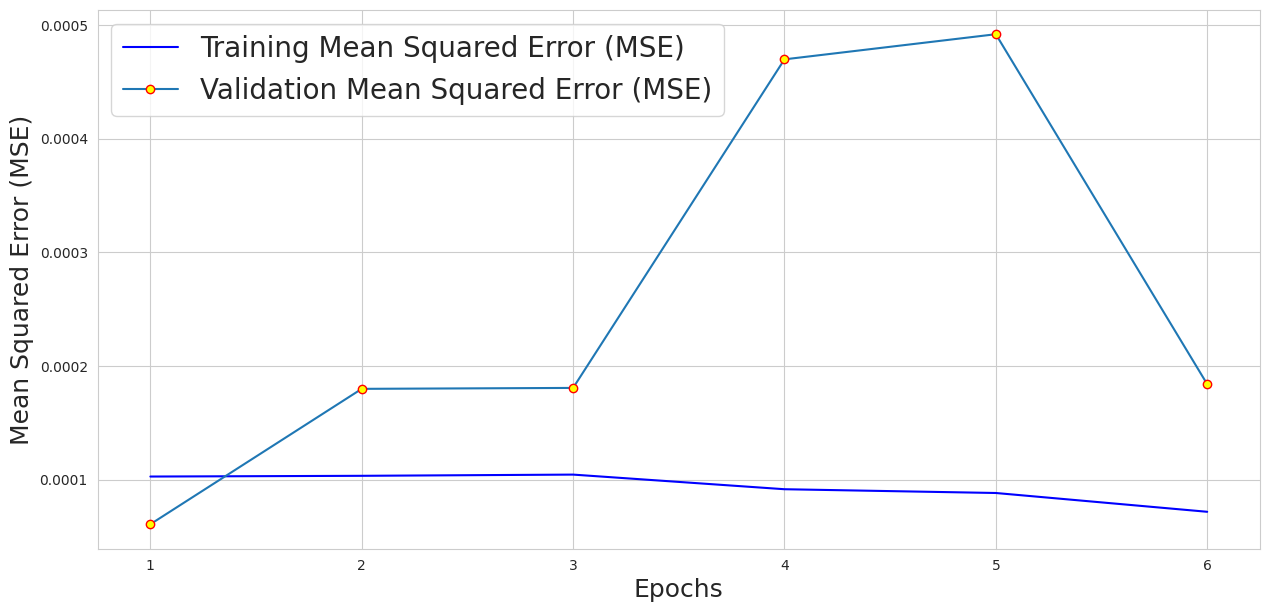

In [91]:
# deleted the 1st epoch
# to examine in detail the results of the remaining epochs

history_dict = history.history

mse_values = history_dict['loss'][1:]
val_mse_values = history_dict['val_loss'][1:]

epochs = range(1, len(mse_values) + 1)
plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, mse_values, 'b', label='Training Mean Squared Error (MSE)')
plt.plot(epochs, val_mse_values, marker='o', markeredgecolor='red', markerfacecolor='yellow', label='Validation Mean Squared Error (MSE)')
plt.xlabel('Epochs', size=18)
plt.ylabel('Mean Squared Error (MSE)', size=18)
plt.legend()
plt.show();

#### MAE graphs during training

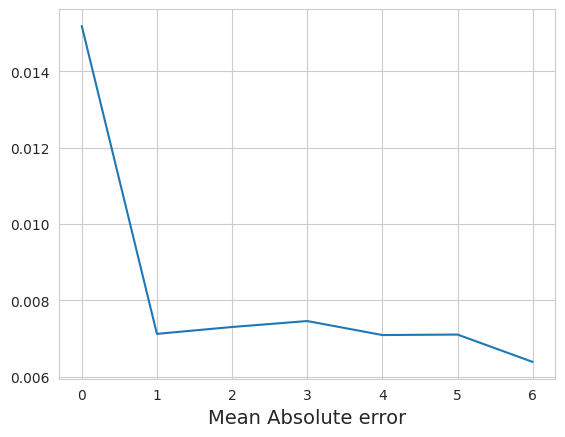

In [92]:
# Training Mean Absolute Error(MAE)

plt.plot(history.history['mae'])
plt.xlabel('Mean Absolute error',size=14)
plt.show();

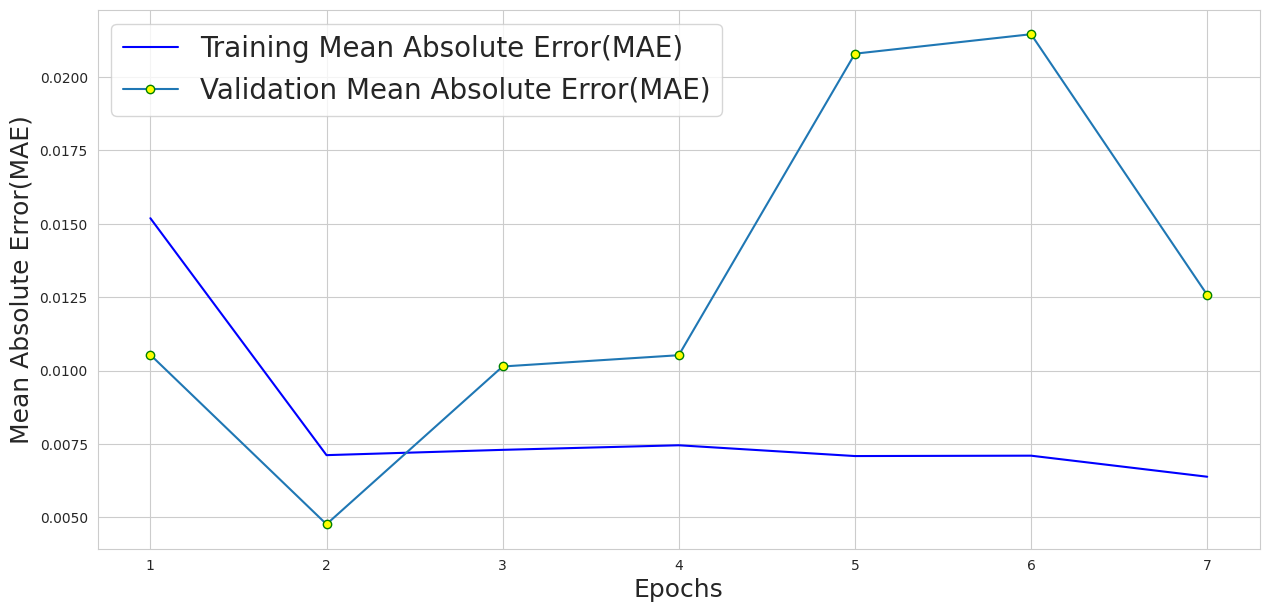

In [93]:
# More detailed MAE graph

history_dict = history.history

mae_values = history_dict['mae']
val_mae_values = history_dict['val_mae']

epochs = range(1, len(mae_values) + 1)
plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, mae_values, 'b', label='Training Mean Absolute Error(MAE)')
plt.plot(epochs, val_mae_values, marker='o', markeredgecolor='green', markerfacecolor='yellow', label='Validation Mean Absolute Error(MAE)')
plt.xlabel('Epochs', size=18)
plt.ylabel('Mean Absolute Error(MAE)', size=18)
plt.legend()
plt.show()

### prediction 25 minute ahead

In [94]:
pred = LSTM_saved_best_model_Silver_3D(X_test)


In [95]:
print(pred)

tf.Tensor(
[[2.3715804 2.3710728]
 [2.372839  2.3695564]
 [2.3720303 2.372416 ]
 ...
 [2.278809  2.2788796]
 [2.2791748 2.278007 ]
 [2.279418  2.2774572]], shape=(3517, 2), dtype=float32)


In [96]:
len(pred)

3517

### Price chart

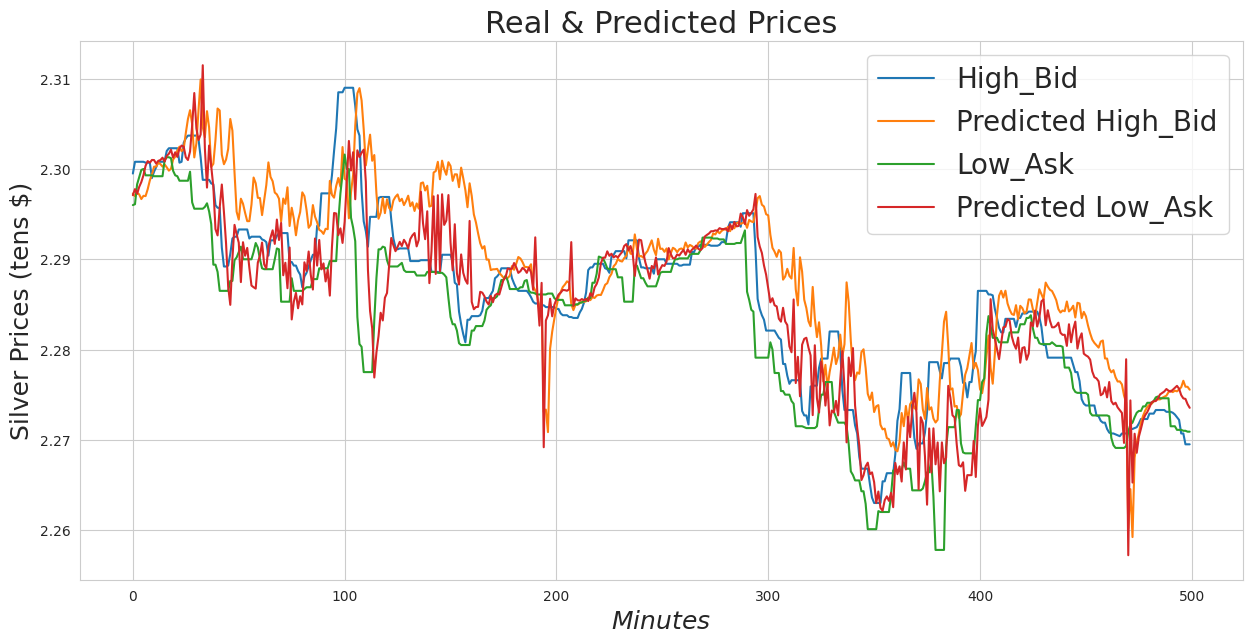

In [97]:
N1=2500  # The first minute for the chart
LL = 500  # Duration (in minutes) for the chart
N2=N1+LL  # the last minute for the chart

plt.ion()
fig = plt.figure(figsize=(15,7))

ax1 = fig.add_subplot(111)
line1, = ax1.plot(y_test[N1:N2,0], label='High_Bid')
line2, = ax1.plot(pred[N1:N2,0], label='Predicted High_Bid')
line3, = ax1.plot(y_test[N1:N2,1], label='Low_Ask')
line4, = ax1.plot(pred[N1:N2,1], label='Predicted Low_Ask')

plt.title('Real & Predicted Prices', size=22)
plt.ylabel('Silver Prices (tens $)', size=18)
plt.xlabel('$Minutes$', size=18)
plt.legend(loc='upper right')

plt.show()


### Error Chart

In [98]:
# For 6 months 2023:

max_price = 26.153
min_price = 19.888
average_price = (max_price + min_price)/2


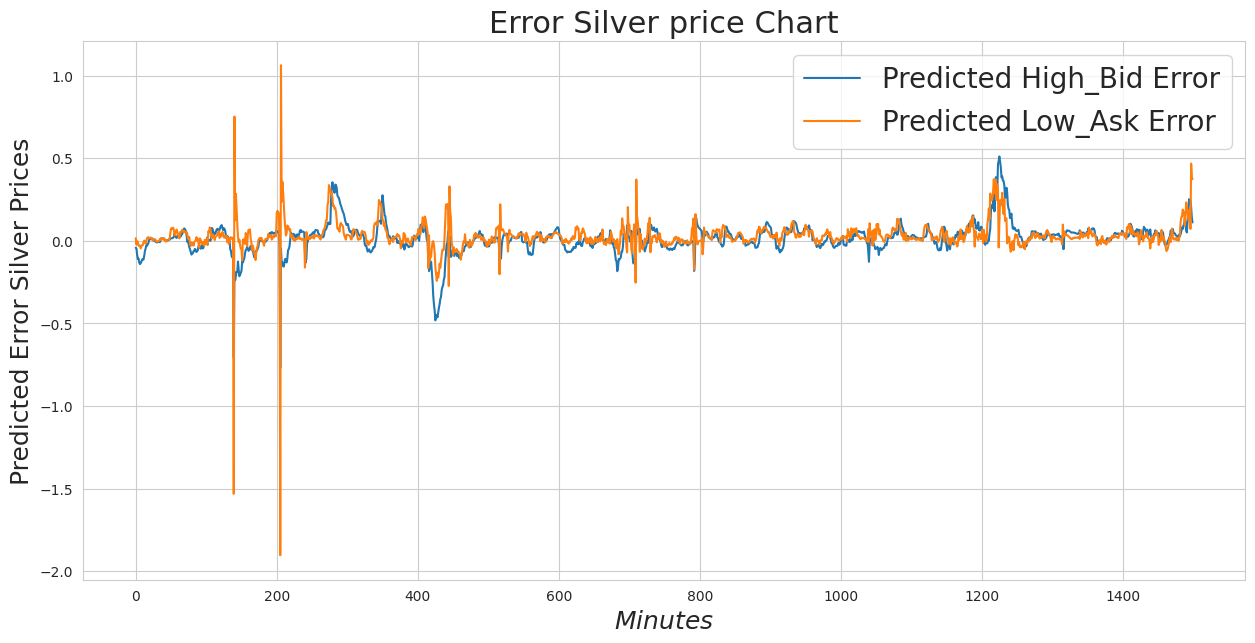

In [99]:
N1=0  # The first minute for the chart
LL = 1500  # leigt (in minutes) for the chart
N2=N1+LL  # the last minute for the chart
# N2 should be < len(pred)

plt.ion()
fig = plt.figure(figsize=(15,7))

ax1 = fig.add_subplot(111)

# in $ (absolute price)
a = (pred[N1:N2,0] - y_test[N1:N2,0]) *10
b = (pred[N1:N2,1] - y_test[N1:N2,1]) *10

# in %
#a = (pred[N1:N2,0] - y_test[N1:N2,0]) *1000/ average_price *100
#b = (pred[N1:N2,1] - y_test[N1:N2,1]) *1000/ average_price *100


line1, = ax1.plot(a, label='Predicted High_Bid Error')
line2, = ax1.plot(b, label='Predicted Low_Ask Error')

plt.title('Error Silver price Chart', size=22)
plt.ylabel('Predicted Error Silver Prices', size=18)
plt.xlabel('$Minutes$', size=18)
plt.legend(loc='upper right')

plt.show()

# Lab Logbook Requirement:

<html> <h3 style="font-style:italic; color:blue;">
   
1) Modify the practical session LSTM model parameter from 100 to be calculated using the formula:

   ZY + 10
   , where your SID is: XXXXXZY

   For example, if your SID is 2287167,
   LSTM parameter = 67+10 = 77
   
3) Change the epochs to 10
4) Change the patience to 5
5) Leave other parameters the same as in the practical session.
6) Compile the model.
6) Train your LSTM with the same datasets and demonstrate the received test MSE & MAE.
Compare your test MSE & MAE with the MSE & MAE of the LSTM in the practical session.
7) Please only add to your Lab Logbook print-screens of:
- your LSTM architecture using model.summary()
- code and training result using model.fit()
- the resulting test MSE & MAE and
- MAE detailed graph.
    
</h3> </html>

<html> <h3 style="color:red;">
NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK ON GITHUB.
</h3> </html>

# Solution:

In [100]:
# For example, if your SID is 2287167, so:

# LSTM parametr = 67+10 = 77
# epochs = 10
# patience = 3

In [101]:
# Sid = 2461421

model_1 = keras.Sequential([

    keras.layers.LSTM(31, activation='relu', input_shape=(50, 18)),

    keras.layers.Dense(2)

])


In [102]:
print(model_1.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 31)             │         6,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            64 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,264 (24.47 KB)

 Trainable params: 6,264 (24.47 KB)

 Non-trainable params: 0 (0.00 B)

None


In [103]:
model_1.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [104]:
es = EarlyStopping(monitor='val_loss', mode='min', patience=5, verbose=1)

In [105]:
mc = ModelCheckpoint('best_model_LSTM_Silver_3D_Logbook.keras', monitor='val_loss', mode='min', verbose=1, save_best_only=True)

In [106]:
history_1 = model_1.fit(X_train, y_train, batch_size=20, epochs=10,
                    validation_split=0.1, shuffle=True,
                    verbose=1, callbacks=[es, mc])

Epoch 1/10
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4679 - mae: 0.1518
Epoch 1: val_loss improved from None to 0.00014, saving model to best_model_LSTM_Silver_3D_Logbook.keras

Epoch 1: finished saving model to best_model_LSTM_Silver_3D_Logbook.keras
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 0.0667 - mae: 0.0410 - val_loss: 1.3733e-04 - val_mae: 0.0097
Epoch 2/10
1423/1425 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6313e-04 - mae: 0.0096
Epoch 2: val_loss improved from 0.00014 to 0.00009, saving model to best_model_LSTM_Silver_3D_Logbook.keras

Epoch 2: finished saving model to best_model_LSTM_Silver_3D_Logbook.keras
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 1.3542e-04 - mae: 0.0086 - val_loss: 9.3853e-05 - val_mae: 0.0073
Epoch 3/10
1422/1425 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.4303e-05 - mae: 0.0072
Epoch 3: val_loss improved from 0.00009 to 0.00007, saving model to best_model_LSTM_Silver_3D_Logbook.keras

Epoch 3: finished saving model to best_m

In [107]:
# Upload the saved best model

LSTM_saved_best_3D_model_1 = keras.models.load_model('best_model_LSTM_Silver_3D_Logbook.keras')

In [108]:
# Evaluate the quality of network training on test data, which the network has NOT seen.

scores_1 = LSTM_saved_best_3D_model_1.evaluate(X_test, y_test, verbose=1)

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.6492e-05 - mae: 0.0032


In [109]:
print("Mean squared error (mse): %.9f " % (scores_1[0]))
print("Mean absolute error (mae): %.9f " % (scores_1[1]))

Mean squared error (mse): 0.000026492 
Mean absolute error (mae): 0.003211458 


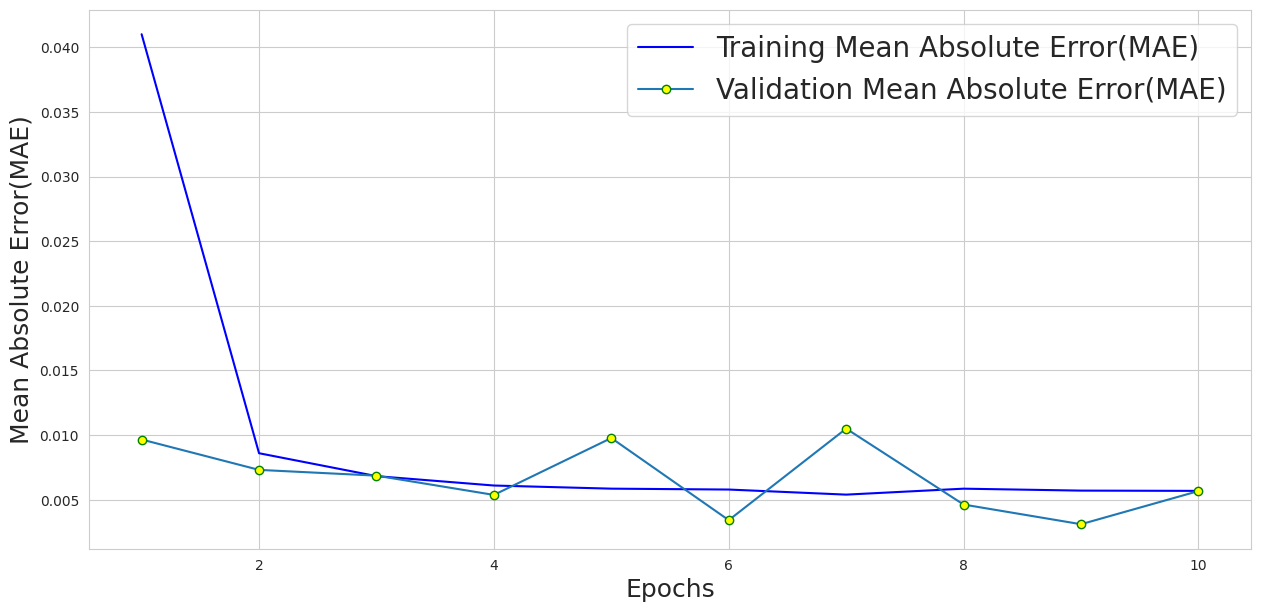

In [110]:
# More detailed MAE graph

history_dict = history_1.history
#plt.style.use('seaborn-darkgrid')
mae_values = history_dict['mae']

val_mae_values = history_dict['val_mae']

epochs = range(1, len(mae_values) + 1)
plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, mae_values, 'b', label='Training Mean Absolute Error(MAE)')
plt.plot(epochs, val_mae_values, marker='o', markeredgecolor='green', markerfacecolor='yellow', label='Validation Mean Absolute Error(MAE)')
plt.xlabel('Epochs', size=18)
plt.ylabel('Mean Absolute Error(MAE)', size=18)
plt.legend()
plt.show()